# Experiment Analysis
Analysis of travel time and delay across 5 bridge breakdown scenarios on the Bangladesh road network (N1, N2 + side roads).

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
IMG_DIR = '../img'
os.makedirs(IMG_DIR, exist_ok=True)

# Load all scenario data
scenarios = {}
for i in range(5):
    name = f'scenario {i}'
    path = f'../experiment/{name}.csv'
    scenarios[name] = pd.read_csv(path)
    print(f'{name}: {len(scenarios[name])} trips')

# Combine into single DataFrame
df_all = pd.concat(scenarios.values(), ignore_index=True)
df_all['travel_time_hrs'] = df_all['travel_time'] / 60
df_all['total_waiting_time_hrs'] = df_all['total_waiting_time'] / 60
print(f'\nTotal trips: {len(df_all)}')

scenario 0: 251978 trips
scenario 1: 251961 trips
scenario 2: 251513 trips
scenario 3: 249615 trips
scenario 4: 245440 trips

Total trips: 1250507


## 1. Summary Statistics per Scenario

In [60]:
summary = df_all.groupby('scenario').agg(
    trips=('travel_time', 'count'),
    mean_travel_min=('travel_time', 'mean'),
    median_travel_min=('travel_time', 'median'),
    std_travel_min=('travel_time', 'std'),
    max_travel_min=('travel_time', 'max'),
    mean_wait_min=('total_waiting_time', 'mean'),
    median_wait_min=('total_waiting_time', 'median'),
    max_wait_min=('total_waiting_time', 'max'),
    pct_delayed=('total_waiting_time', lambda x: (x > 0).mean() * 100),
).round(1)
summary = summary.sort_index()
print(summary.to_string())

             trips  mean_travel_min  median_travel_min  std_travel_min  max_travel_min  mean_wait_min  median_wait_min  max_wait_min  pct_delayed
scenario                                                                                                                                         
scenario 0  251978            202.1              177.0           135.5             609            0.0              0.0             0          0.0
scenario 1  251961            202.6              180.0           135.5             609            0.5              0.0            59          2.4
scenario 2  251513            211.8              181.0           145.9             766           10.4              0.0           176         27.8
scenario 3  249615            264.0              231.0           184.0             989           64.1             44.0           398         79.1
scenario 4  245440            370.4              306.0           280.0            1778          174.7            131.0      

## 2. Travel Time Distribution – Boxplot by Scenario

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_85265/2611477434.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='scenario', y='travel_time_hrs', ax=ax,


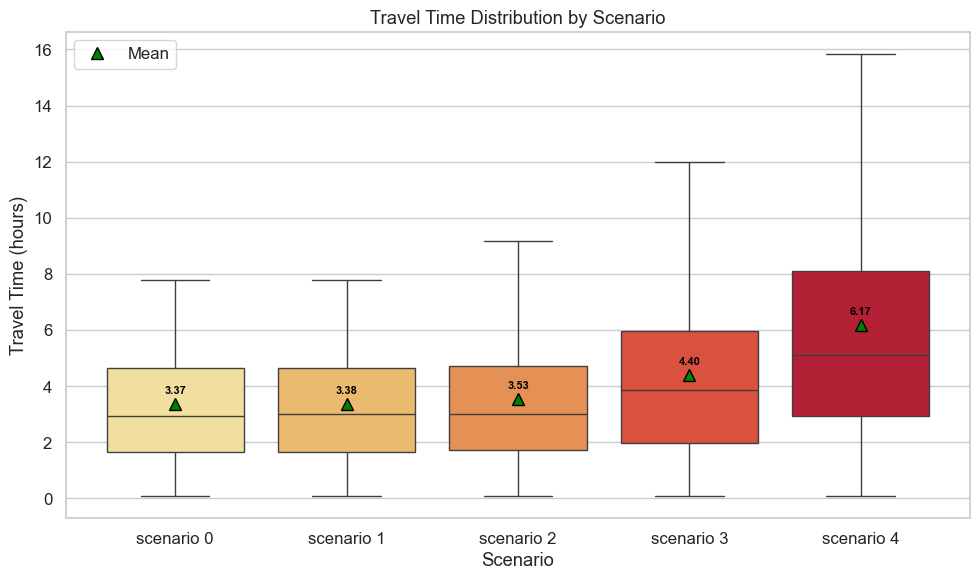

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_all, x='scenario', y='travel_time_hrs', ax=ax,
            order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', showfliers=False, showmeans=True,
            meanprops=dict(marker='^', markerfacecolor='green', markeredgecolor='black', markersize=8))

# Add mean value labels
scenario_order = [f'scenario {i}' for i in range(5)]
means = df_all.groupby('scenario')['travel_time_hrs'].mean().reindex(scenario_order)
for j, val in enumerate(means):
    ax.text(j, val + 0.3, f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')

# Legend for mean marker
ax.plot([], [], marker='^', color='green', markeredgecolor='black', markersize=8, linestyle='None', label='Mean')
ax.legend(loc='upper left')

ax.set_xlabel('Scenario')
ax.set_ylabel('Travel Time (hours)')
ax.set_title('Travel Time Distribution by Scenario')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_travel_time.png'), dpi=150)
plt.show()

## 3. Waiting Time Distribution – Boxplot by Scenario

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_85265/3729290549.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_delayed, x='scenario', y='total_waiting_time_hrs', ax=ax,


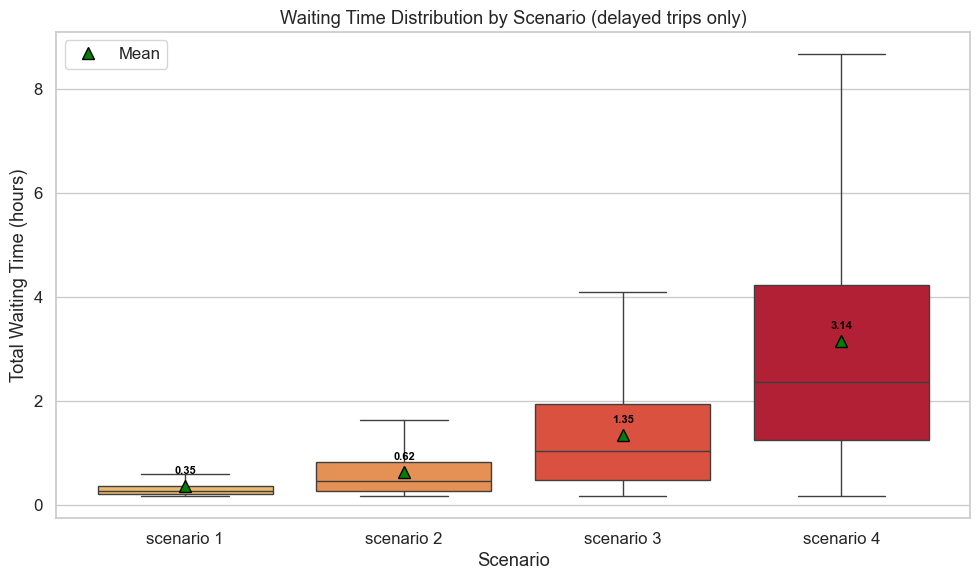

In [62]:
# Only include trips that experienced delay
df_delayed = df_all[df_all['total_waiting_time'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_delayed, x='scenario', y='total_waiting_time_hrs', ax=ax,
            order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', showfliers=False, showmeans=True,
            meanprops=dict(marker='^', markerfacecolor='green', markeredgecolor='black', markersize=8))

# Add mean value labels
scenario_order = [f'scenario {i}' for i in range(5)]
means = df_delayed.groupby('scenario')['total_waiting_time_hrs'].mean().reindex(scenario_order)
for j, val in enumerate(means):
    if pd.notna(val):
        ax.text(j, val + 0.2, f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')

ax.plot([], [], marker='^', color='green', markeredgecolor='black', markersize=8, linestyle='None', label='Mean')
ax.legend(loc='upper left')

ax.set_xlabel('Scenario')
ax.set_ylabel('Total Waiting Time (hours)')
ax.set_title('Waiting Time Distribution by Scenario (delayed trips only)')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_waiting_time.png'), dpi=150)
plt.show()

## 4. Travel Time Histogram – Scenario 0 vs Scenario 4

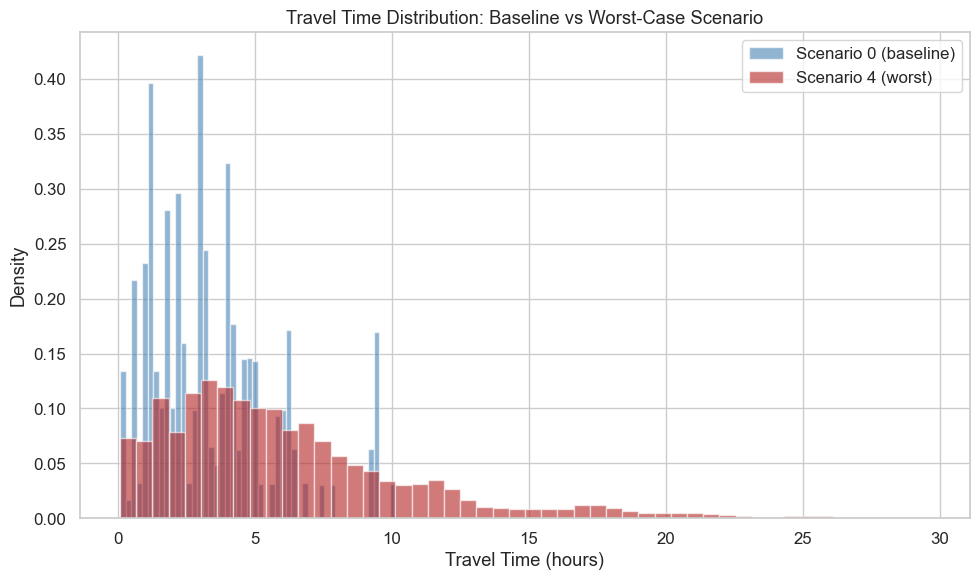

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
for scen, color, label in [('scenario 0', 'steelblue', 'Scenario 0 (baseline)'),
                            ('scenario 4', 'firebrick', 'Scenario 4 (worst)')]:
    data = df_all[df_all['scenario'] == scen]['travel_time_hrs']
    ax.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Travel Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Travel Time Distribution: Baseline vs Worst-Case Scenario')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'histogram_travel_time_s0_vs_s4.png'), dpi=150)
plt.show()

## 5. Mean Travel Time per Replication – Variability Across Seeds

/var/folders/3z/t1bz7z3d0fs08l_5qyn62xlm0000gn/T/ipykernel_85265/3886715759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rep_means, x='scenario', y='mean_travel', ax=ax,


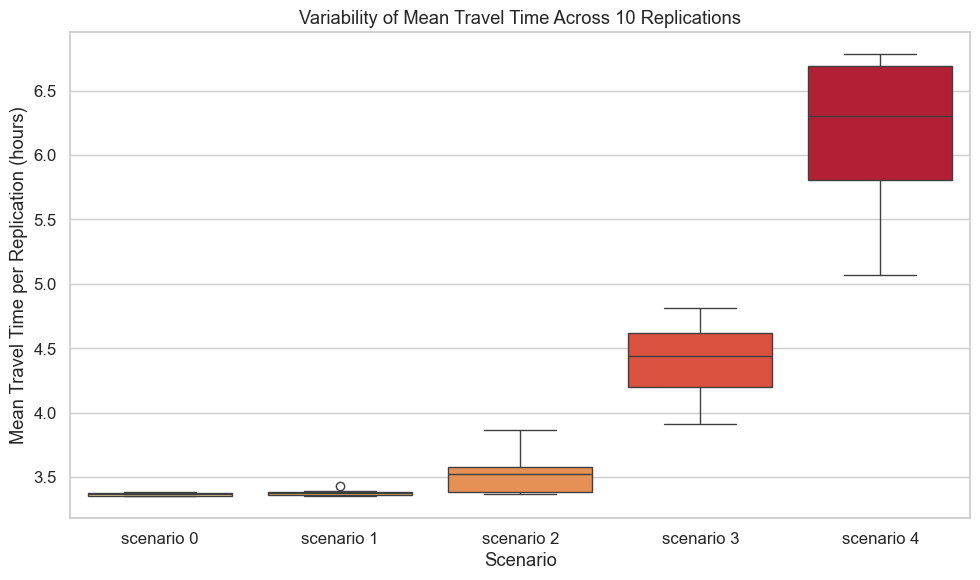

In [64]:
rep_means = df_all.groupby(['scenario', 'replication']).agg(
    mean_travel=('travel_time_hrs', 'mean'),
    mean_wait=('total_waiting_time_hrs', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=rep_means, x='scenario', y='mean_travel', ax=ax,
            order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd')
ax.set_xlabel('Scenario')
ax.set_ylabel('Mean Travel Time per Replication (hours)')
ax.set_title('Variability of Mean Travel Time Across 10 Replications')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'boxplot_replication_variability.png'), dpi=150)
plt.show()

## 6. Mean Travel Time by Origin Road per Scenario

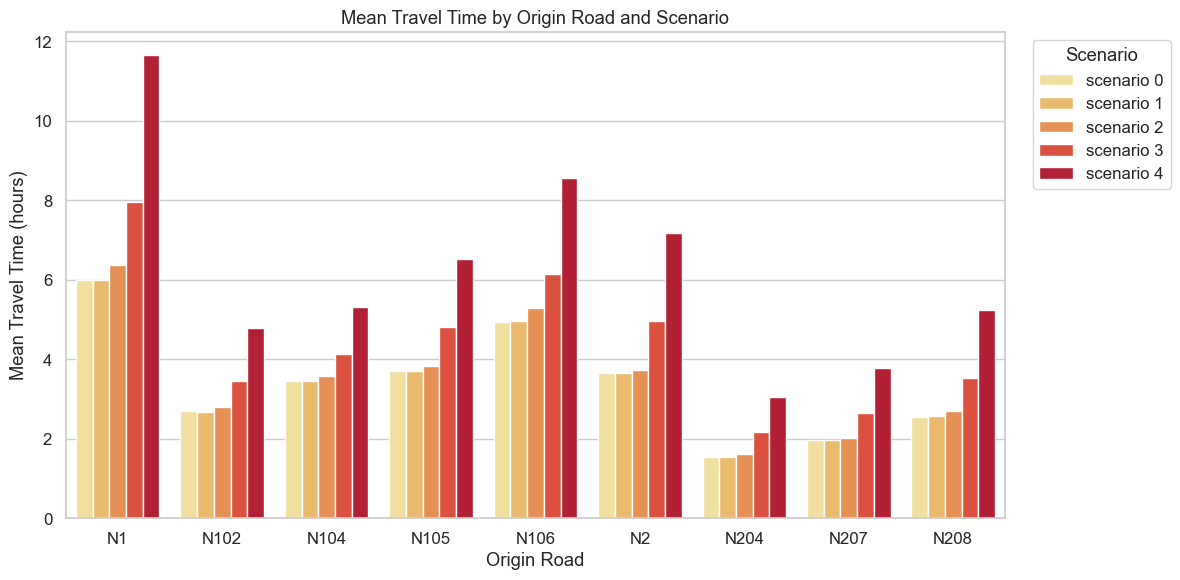

In [65]:
road_means = df_all.groupby(['scenario', 'origin_road'])['travel_time_hrs'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=road_means, x='origin_road', y='travel_time_hrs', hue='scenario',
            hue_order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', ax=ax)
ax.set_xlabel('Origin Road')
ax.set_ylabel('Mean Travel Time (hours)')
ax.set_title('Mean Travel Time by Origin Road and Scenario')
ax.legend(title='Scenario', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'barplot_travel_by_road.png'), dpi=150)
plt.show()

## 7. Scenario Comparison – Bar Chart (Mean Travel Time & Waiting Time)

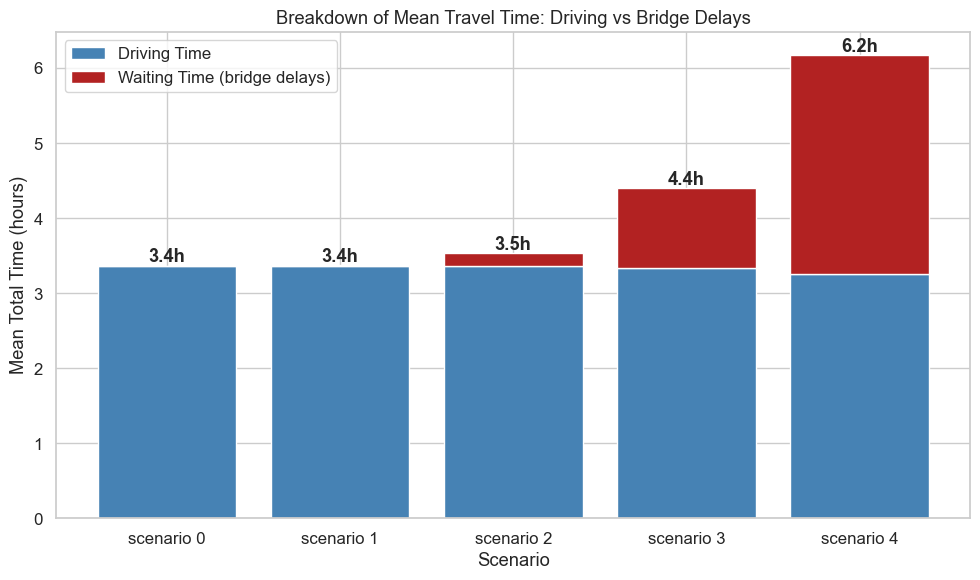

In [66]:
scenario_order = [f'scenario {i}' for i in range(5)]
means = df_all.groupby('scenario').agg(
    driving_time=('travel_time_hrs', 'mean'),
    waiting_time=('total_waiting_time_hrs', 'mean')
).reindex(scenario_order)
means['pure_driving'] = means['driving_time'] - means['waiting_time']

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(range(5), means['pure_driving'], label='Driving Time', color='steelblue')
bars2 = ax.bar(range(5), means['waiting_time'], bottom=means['pure_driving'],
               label='Waiting Time (bridge delays)', color='firebrick')
ax.set_xticks(range(5))
ax.set_xticklabels(scenario_order)
ax.set_xlabel('Scenario')
ax.set_ylabel('Mean Total Time (hours)')
ax.set_title('Breakdown of Mean Travel Time: Driving vs Bridge Delays')
ax.legend()

# Add total labels
for i, total in enumerate(means['driving_time']):
    ax.text(i, total + 0.05, f'{total:.1f}h', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'stacked_bar_driving_vs_waiting.png'), dpi=150)
plt.show()

## 8. Percentage of Delayed Trips per Scenario

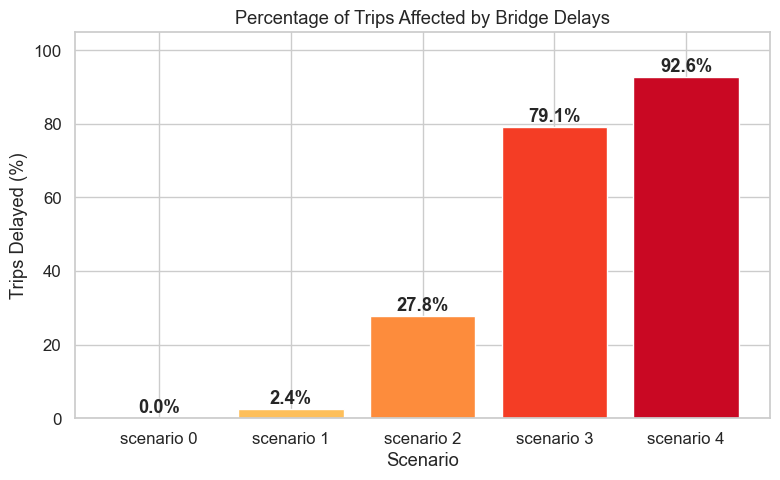

In [67]:
pct_delayed = df_all.groupby('scenario')['total_waiting_time'].apply(
    lambda x: (x > 0).mean() * 100
).reindex(scenario_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(5), pct_delayed, color=sns.color_palette('YlOrRd', 5))
ax.set_xticks(range(5))
ax.set_xticklabels(scenario_order)
ax.set_xlabel('Scenario')
ax.set_ylabel('Trips Delayed (%)')
ax.set_title('Percentage of Trips Affected by Bridge Delays')
ax.set_ylim(0, 105)

for i, pct in enumerate(pct_delayed):
    ax.text(i, pct + 1.5, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'bar_pct_delayed.png'), dpi=150)
plt.show()

## 9. Summary Table for Report

In [68]:
breakdown_labels = {
    'scenario 0': 'A=0%, B=0%, C=0%, D=0%',
    'scenario 1': 'A=0%, B=0%, C=0%, D=5%',
    'scenario 2': 'A=0%, B=0%, C=5%, D=10%',
    'scenario 3': 'A=0%, B=5%, C=10%, D=20%',
    'scenario 4': 'A=5%, B=10%, C=20%, D=40%',
}

report_table = df_all.groupby('scenario').agg(
    total_trips=('travel_time', 'count'),
    mean_travel_hrs=('travel_time_hrs', 'mean'),
    median_travel_hrs=('travel_time_hrs', 'median'),
    mean_wait_hrs=('total_waiting_time_hrs', 'mean'),
    max_wait_hrs=('total_waiting_time_hrs', 'max'),
    pct_delayed=('total_waiting_time', lambda x: (x > 0).mean() * 100),
    mean_bridges=('bridges_passed', 'mean'),
).round(2)

report_table['breakdown_probs'] = report_table.index.map(breakdown_labels)
report_table = report_table.reindex(scenario_order)
print(report_table.to_string())

            total_trips  mean_travel_hrs  median_travel_hrs  mean_wait_hrs  max_wait_hrs  pct_delayed  mean_bridges            breakdown_probs
scenario                                                                                                                                      
scenario 0       251978             3.37               2.95           0.00          0.00         0.00         98.51     A=0%, B=0%, C=0%, D=0%
scenario 1       251961             3.38               3.00           0.01          0.98         2.41         98.53     A=0%, B=0%, C=0%, D=5%
scenario 2       251513             3.53               3.02           0.17          2.93        27.79         98.40    A=0%, B=0%, C=5%, D=10%
scenario 3       249615             4.40               3.85           1.07          6.63        79.09         98.11   A=0%, B=5%, C=10%, D=20%
scenario 4       245440             6.17               5.10           2.91         20.45        92.64         96.87  A=5%, B=10%, C=20%, D=40%

## 10. Top 5 Bridges Causing Most Delay (per Scenario)

In [69]:
# Load bridge data for all scenarios
bridge_scenarios = {}
for i in range(5):
    name = f'scenario {i}'
    path = f'../experiment/{name} bridges.csv'
    try:
        bridge_scenarios[name] = pd.read_csv(path)
        bridge_scenarios[name]['scenario'] = name
        print(f'{name}: {len(bridge_scenarios[name])} bridge records')
    except FileNotFoundError:
        print(f'{name}: bridge file not found')

df_bridges = pd.concat(bridge_scenarios.values(), ignore_index=True)
df_bridges['total_delay_hrs'] = df_bridges['total_delay_min'] / 60
print(f'\nTotal bridge records: {len(df_bridges)}')

scenario 0: 7370 bridge records
scenario 1: 7370 bridge records
scenario 2: 7370 bridge records
scenario 3: 7370 bridge records
scenario 4: 7370 bridge records

Total bridge records: 36850


In [70]:
# Find top 5 bridges per scenario by averaging total delay across replications
for scenario_name in [f'scenario {i}' for i in range(1, 5)]:
    df_s = df_bridges[df_bridges['scenario'] == scenario_name]
    
    top5 = df_s.groupby(['bridge_id', 'name', 'road', 'condition', 'length']).agg(
        avg_delay_min=('total_delay_min', 'mean'),
        avg_vehicles_delayed=('vehicles_delayed', 'mean'),
        times_broken=('broken_down', 'sum'),
    ).reset_index().nlargest(5, 'avg_delay_min')
    
    top5['avg_delay_hrs'] = (top5['avg_delay_min'] / 60).round(1)
    print(f'\n=== {scenario_name.upper()} - Top 5 Bridges ===')
    print(top5[['bridge_id', 'name', 'road', 'condition', 'length',
                'avg_delay_hrs', 'avg_vehicles_delayed', 'times_broken']].to_string(index=False))



=== SCENARIO 1 - Top 5 Bridges ===
 bridge_id                                                 name road condition  length  avg_delay_hrs  avg_vehicles_delayed  times_broken
   7000114                                        UTTOR KALAPUR N207         D      13          114.2                 184.7             1
   9000152 CHAIRMAN GHAT BOX CULVERT(R) (2 bridges at crossing) N106         D       2          106.4                 440.6             2
   1000015                                       Kachpur bridge   N1         B       0            0.0                   0.0             0
   1000025                                     NOYAPARA CULVERT   N1         A       6            0.0                   0.0             0
   1000027                          NAYABARI KASPUR BOX CULVERT   N1         A       8            0.0                   0.0             0

=== SCENARIO 2 - Top 5 Bridges ===
 bridge_id                                             name road condition  length  avg_delay_hrs  a

## 11. Top 5 Bridges for Investment (Averaged Across Scenarios 1–4)

Following the same methodology as Assignment 2, scenarios 1–4 are weighted equally.
Bridges are ranked by their **average total delay** across all scenarios and replications.

=== TOP 5 BRIDGES FOR INVESTMENT (Scenarios 1-4, Equal Weight) ===
 bridge_id                                                      name road condition  length  avg_delay_hrs  avg_vehicles_delayed
   2000783                   SHALIPUR BRIDGE (2 bridges at crossing)   N2         C     161          886.6               793.425
   2000175 BRIDE OVER ARIAL RCC GIDER BRIDGE (2 bridges at crossing)   N2         C     140          591.9               530.075
   2000217                                           OLD BRAMMAPULRA   N2         C     429          569.6               265.575
   1000450                                   PURPU DURGAPURE BOX CUL   N1         C      12          515.5               834.075
   2000248                 Sonarampur Bridge (2 bridges at crossing)   N2         C      80          441.4               395.750


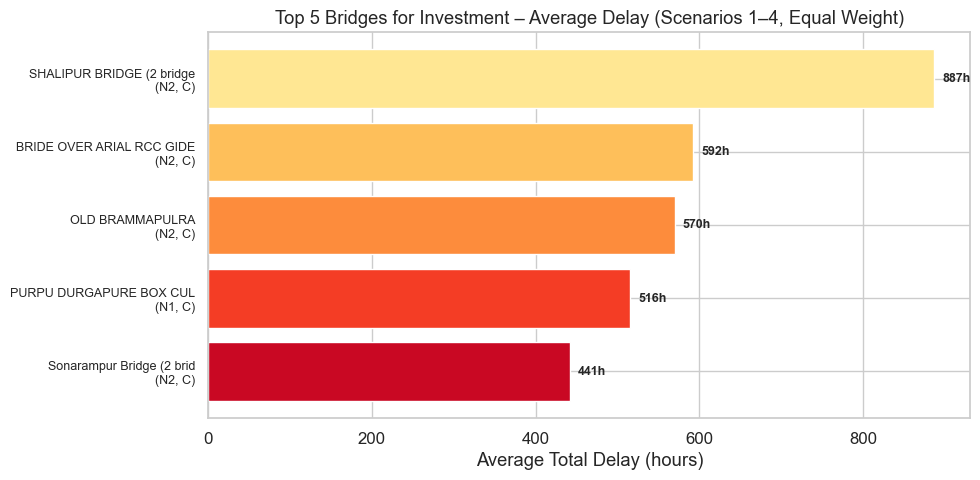

In [71]:
# Average delay across scenarios 1-4 and all replications (equal weight per scenario)
df_bridges_active = df_bridges[df_bridges['scenario'] != 'scenario 0'].copy()

# First average within each scenario (across replications), then average across scenarios
per_scenario = df_bridges_active.groupby(
    ['bridge_id', 'name', 'road', 'condition', 'length', 'scenario']
).agg(
    mean_delay_min=('total_delay_min', 'mean'),
    mean_vehicles=('vehicles_delayed', 'mean'),
).reset_index()

overall = per_scenario.groupby(
    ['bridge_id', 'name', 'road', 'condition', 'length']
).agg(
    avg_delay_min=('mean_delay_min', 'mean'),
    avg_vehicles_delayed=('mean_vehicles', 'mean'),
).reset_index()

top5_overall = overall.nlargest(5, 'avg_delay_min')
top5_overall['avg_delay_hrs'] = (top5_overall['avg_delay_min'] / 60).round(1)
top5_overall['label'] = top5_overall['name'].str[:25] + '\n(' + top5_overall['road'] + ', ' + top5_overall['condition'] + ')'

print('=== TOP 5 BRIDGES FOR INVESTMENT (Scenarios 1-4, Equal Weight) ===')
print(top5_overall[['bridge_id', 'name', 'road', 'condition', 'length',
                    'avg_delay_hrs', 'avg_vehicles_delayed']].to_string(index=False))

# Bar chart - average total delay
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('YlOrRd', 5)
ax.barh(range(5), top5_overall['avg_delay_hrs'].values, color=colors)
ax.set_yticks(range(5))
ax.set_yticklabels(top5_overall['label'].values, fontsize=9)
ax.set_xlabel('Average Total Delay (hours)')
ax.set_title('Top 5 Bridges for Investment – Average Delay (Scenarios 1–4, Equal Weight)')
ax.invert_yaxis()
for j, v in enumerate(top5_overall['avg_delay_hrs'].values):
    ax.text(v + 10, j, f'{v:.0f}h', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'top5_bridges_investment.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Top 5 Bridges – Delay Breakdown by Scenario

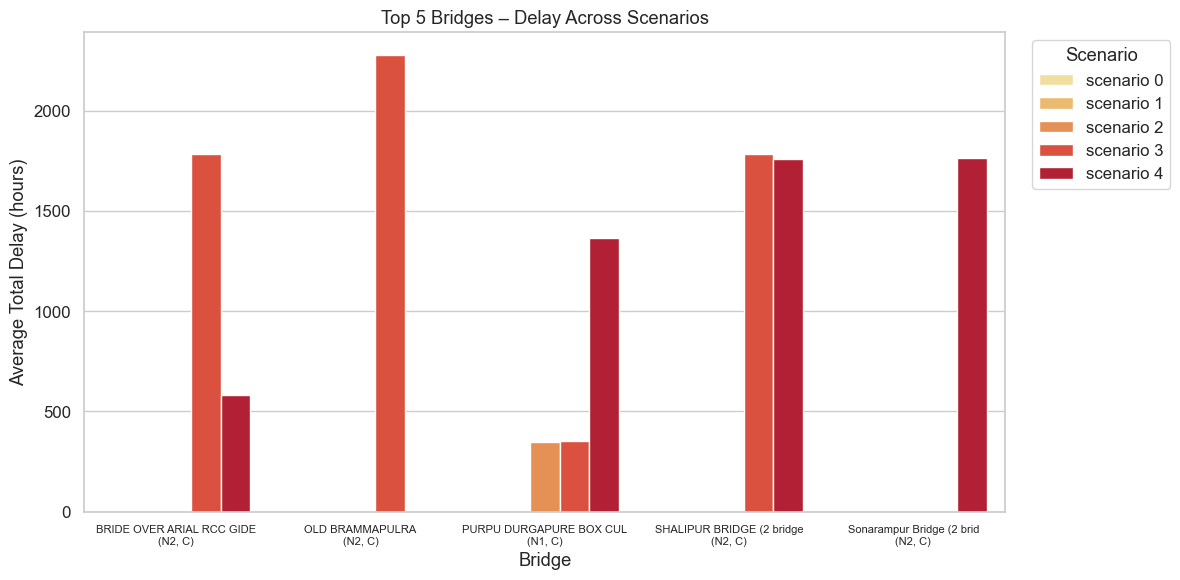

In [72]:
# Show how the top 5 bridges' delay varies across scenarios
top5_ids = top5_overall['bridge_id'].tolist()
top5_names = dict(zip(top5_overall['bridge_id'], top5_overall['label']))

df_top_across = df_bridges[df_bridges['bridge_id'].isin(top5_ids)].copy()
df_top_across['label'] = df_top_across['bridge_id'].map(top5_names)

# Average delay per bridge per scenario
pivot = df_top_across.groupby(['scenario', 'label'])['total_delay_hrs'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=pivot, x='label', y='total_delay_hrs', hue='scenario',
            hue_order=[f'scenario {i}' for i in range(5)],
            palette='YlOrRd', ax=ax)
ax.set_xlabel('Bridge')
ax.set_ylabel('Average Total Delay (hours)')
ax.set_title('Top 5 Bridges – Delay Across Scenarios')
ax.legend(title='Scenario', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'top5_bridges_across_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Top 5 Bridges – Location on Network Map

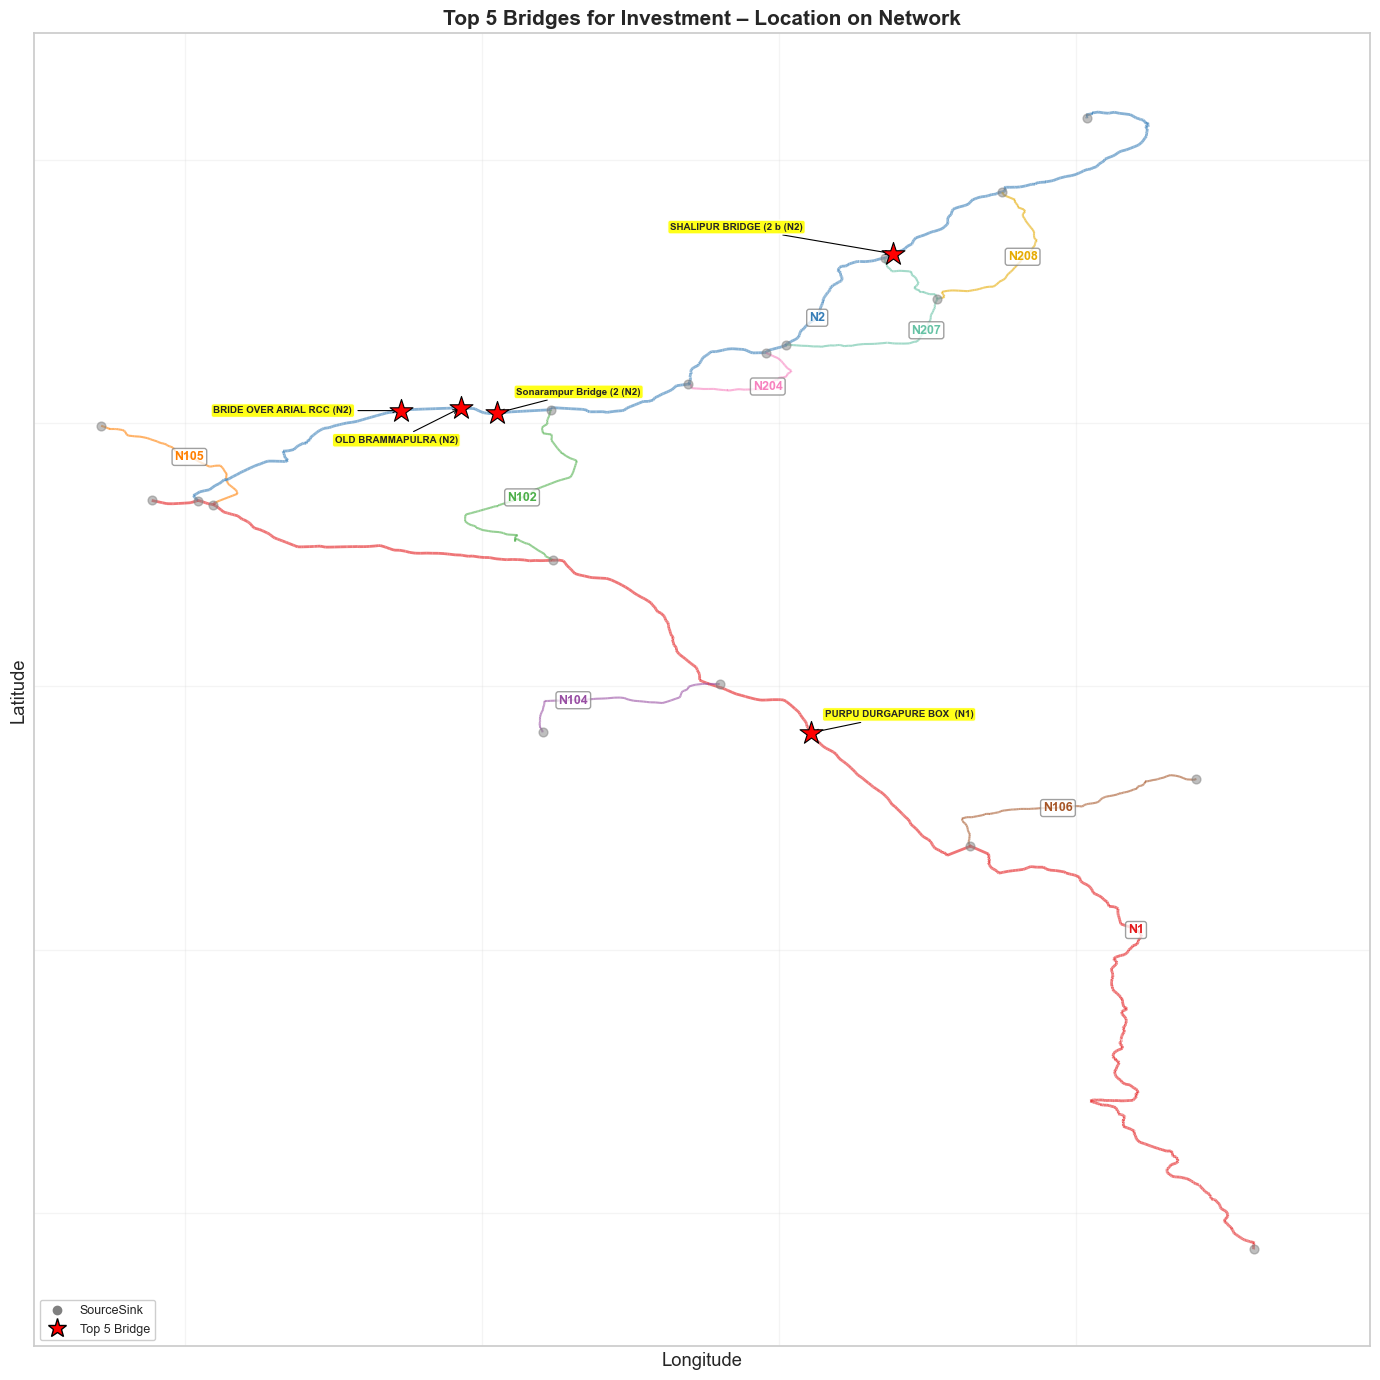

In [73]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# Load network data and build graph for map
df_net = pd.read_csv('../data/network_data.csv')

# Get positions from CSV
node_pos = {}
node_road = {}
node_type = {}

for _, row in df_net.iterrows():
    nid = int(row['id'])
    if nid not in node_pos:
        node_pos[nid] = (row['lon'], row['lat'])
        node_road[nid] = row['road']
        node_type[nid] = row['model_type'].strip()

# Build graph
G = nx.Graph()
for road in df_net['road'].unique():
    road_ids = df_net[df_net['road'] == road]['id'].tolist()
    for j in range(len(road_ids) - 1):
        G.add_edge(int(road_ids[j]), int(road_ids[j + 1]))

road_colors = {
    'N1': '#e41a1c',
    'N2': '#377eb8',
    'N102': '#4daf4a',
    'N104': '#984ea3',
    'N105': '#ff7f00',
    'N106': '#a65628',
    'N204': '#f781bf',
    'N207': '#66c2a5',
    'N208': '#e6ab02'
}

# Group edges by road
road_edge_list = {r: [] for r in road_colors}
for u, v in G.edges():
    r = node_road.get(u, node_road.get(v, 'N1'))
    if r in road_edge_list:
        road_edge_list[r].append((u, v))

# Get top 5 bridge positions
top5_bridge_ids = top5_overall['bridge_id'].tolist()
top5_positions = {
    bid: node_pos.get(bid)
    for bid in top5_bridge_ids
    if bid in node_pos
}

top5_labels_map = dict(zip(
    top5_overall['bridge_id'],
    top5_overall['name'].str[:20] + ' (' + top5_overall['road'] + ')'
))

fig, ax = plt.subplots(figsize=(14, 14))

# Draw road edges
for road in road_colors:
    edges = road_edge_list.get(road, [])
    width = 2.0 if road in ('N1', 'N2') else 1.5
    nx.draw_networkx_edges(
        G,
        node_pos,
        edgelist=edges,
        ax=ax,
        edge_color=road_colors[road],
        width=width,
        alpha=0.6
    )

# Draw SourceSink nodes
ss_nodes = [n for n, t in node_type.items() if t == 'sourcesink' and n in G.nodes()]
nx.draw_networkx_nodes(
    G,
    node_pos,
    nodelist=ss_nodes,
    ax=ax,
    node_color='gray',
    node_size=40,
    alpha=0.5
)

# Manual bridge label offsets
label_offsets = {
    'OLD BRAMMAPULRA (N2)': (-2, -20),
    'BRIDE OVER ARIAL RCC (N2)': (-35, 0),
    'Sonarampur Bridge (2 (N2)': (14, 12),
    'SHALIPUR BRIDGE (2 b (N2)': (-65, 16),
    'PURPU DURGAPURE BOX (N1)': (10, 8)
}

# Draw top 5 bridges as stars with labels
for bid in top5_bridge_ids:
    if bid in top5_positions and top5_positions[bid] is not None:
        x, y = top5_positions[bid]

        ax.scatter(
            x, y,
            s=300,
            c='red',
            marker='*',
            zorder=10,
            edgecolors='black',
            linewidths=0.8
        )

        label = top5_labels_map.get(bid, str(bid))
        dx, dy = label_offsets.get(label, (10, 10))

        if dx == 0:
            ha = 'center'
        elif dx > 0:
            ha = 'left'
        else:
            ha = 'right'

        if dy == 0:
            va = 'center'
        elif dy > 0:
            va = 'bottom'
        else:
            va = 'top'

        ax.annotate(
            label,
            (x, y),
            fontsize=7,
            fontweight='bold',
            xytext=(dx, dy),
            textcoords='offset points',
            ha=ha,
            va=va,
            bbox=dict(
                boxstyle='round,pad=0.25',
                fc='yellow',
                alpha=0.9
            ),
            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=0.8
            )
        )

# Build ordered node list for each road
road_node_lists = {}
for road in df_net['road'].unique():
    road_ids = df_net[df_net['road'] == road]['id'].tolist()
    road_node_lists[road] = [int(n) for n in road_ids if int(n) in node_pos]

# Add road labels on the map
for road, nodes in road_node_lists.items():
    if len(nodes) == 0:
        continue

    mid_idx = len(nodes) // 2
    mid_node = nodes[mid_idx]
    x, y = node_pos[mid_node]

    ax.text(
        x, y,
        road,
        fontsize=9,
        fontweight='bold',
        color=road_colors.get(road, 'black'),
        ha='center',
        va='center',
        zorder=6,
        bbox=dict(
            boxstyle='round,pad=0.2',
            fc='white',
            ec='gray',
            alpha=0.75
        )
    )

# Legend: only SourceSink and Top 5 Bridge
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SourceSink',
        markerfacecolor='gray',
        markeredgecolor='gray',
        markersize=6
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='w',
        label='Top 5 Bridge',
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=14
    )
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.95)

ax.set_title('Top 5 Bridges for Investment – Location on Network', fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'top5_bridges_map.png'), dpi=150, bbox_inches='tight')
plt.show()